# Data Analysis and Cleaning - Salary

The following dataset provides information about the job of a Data Engineer. "It includes information such as salary, job title, experience level, employment type, employee residence, remote work ratio, company location, and company size."
Dataset was taken from Kaggle.
*(source: https://www.kaggle.com/datasets/chopper53/data-engineer-salary-in-2024)*

In [506]:
import pandas as pd

In [507]:
df = pd.read_csv('data/salaries (2).csv',
                 encoding='iso-8859-15')

In [508]:
df = df.copy()

In [509]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [510]:
df.count()

work_year             16534
experience_level      16534
employment_type       16534
job_title             16534
salary                16534
salary_currency       16534
salary_in_usd         16534
employee_residence    16534
remote_ratio          16534
company_location      16534
company_size          16534
dtype: int64

In [511]:
df[df.isnull().any(axis=1)]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size


There are no null values and count shows that there are equal amount of data in the dataset.

In [512]:
df.min(axis=0)

work_year                     2020
experience_level                EN
employment_type                 CT
job_title             AI Architect
salary                       14000
salary_currency                AUD
salary_in_usd                15000
employee_residence              AD
remote_ratio                     0
company_location                AD
company_size                     L
dtype: object

The work year should always be at 2024, this represents the year in which the data was collected.

In [513]:
df = df[df['work_year'] >= 2024]

In [514]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
6073,2024,SE,FT,Data Analyst,170000,USD,170000,US,100,US,M
6074,2024,SE,FT,Data Scientist,195500,USD,195500,US,100,US,M
6075,2024,SE,FT,Data Scientist,141300,USD,141300,US,100,US,M
6076,2024,SE,FT,Data Engineer,139810,USD,139810,US,0,US,M


This dataset shows the salary in the local currency in which the salary is denominated. It also converts every currency into USD. Since we live in Austria and use EUR, we will have to change that.

In [515]:
df.rename(columns={'salary_in_usd': 'salary_in_eur'}, inplace=True)

In [516]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
6073,2024,SE,FT,Data Analyst,170000,USD,170000,US,100,US,M
6074,2024,SE,FT,Data Scientist,195500,USD,195500,US,100,US,M
6075,2024,SE,FT,Data Scientist,141300,USD,141300,US,100,US,M
6076,2024,SE,FT,Data Engineer,139810,USD,139810,US,0,US,M


In [517]:
df['salary_in_eur'] = (df['salary_in_eur'] * 0.92330781).round()
# Remove unnseccessary digits
df['salary_in_eur'] = df['salary_in_eur'].apply(lambda x: '{:.0f}'.format(x))
# Convert 'salary_in_eur' column to numeric
df['salary_in_eur'] = pd.to_numeric(df['salary_in_eur'], errors='coerce')

In [518]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,187182,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,85053,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,120492,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,88638,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,175428,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
6073,2024,SE,FT,Data Analyst,170000,USD,156962,US,100,US,M
6074,2024,SE,FT,Data Scientist,195500,USD,180507,US,100,US,M
6075,2024,SE,FT,Data Scientist,141300,USD,130463,US,100,US,M
6076,2024,SE,FT,Data Engineer,139810,USD,129088,US,0,US,M


In [519]:
df.groupby('experience_level').count()

,work_year,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
experience_level,,,,,,,,,,
EN,678,678,678,678,678,678,678,678,678,678
EX,204,204,204,204,204,204,204,204,204,204
MI,1845,1845,1845,1845,1845,1845,1845,1845,1845,1845
SE,3340,3340,3340,3340,3340,3340,3340,3340,3340,3340


The official documentation of this dataset states: 
*"experience_level: The experience level of the employee, categorized as SE (Senior Engineer), MI (Mid-Level Engineer), or EL (Entry-Level Engineer)."*
So the EX should not belong. Let's say it was a typo and it was meant to say EN. (This was likely on purpose, but since the official documentation states otherwise, the reader of the dataset will have certain expectations of what the data will look like, so we will change it accordingly)

In [520]:
df['experience_level'] = df['experience_level'].replace('EX', 'EN')

In [521]:
df.groupby('experience_level').count()

,work_year,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
experience_level,,,,,,,,,,
EN,882,882,882,882,882,882,882,882,882,882
MI,1845,1845,1845,1845,1845,1845,1845,1845,1845,1845
SE,3340,3340,3340,3340,3340,3340,3340,3340,3340,3340


In [522]:
df.groupby('employment_type').count()

,work_year,experience_level,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
employment_type,,,,,,,,,,
CT,9,9,9,9,9,9,9,9,9,9
FL,2,2,2,2,2,2,2,2,2,2
FT,6033,6033,6033,6033,6033,6033,6033,6033,6033,6033
PT,23,23,23,23,23,23,23,23,23,23


Again, the official documentation states: *"employment_type: The type of employment, such as full-time (FT), part-time (PT), contract (C), or freelance (F)."*
FL and CT should be changed to F and C respectively. (Again, this was likely done on purpose, but we want to stay consistent with the official documentation)

In [523]:
df['employment_type'] = df['employment_type'].replace({'FL': 'F', 'CT': 'C'})

In [524]:
df.groupby('employment_type').count()

,work_year,experience_level,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
employment_type,,,,,,,,,,
C,9,9,9,9,9,9,9,9,9,9
F,2,2,2,2,2,2,2,2,2,2
FT,6033,6033,6033,6033,6033,6033,6033,6033,6033,6033
PT,23,23,23,23,23,23,23,23,23,23


In [525]:
df.groupby('remote_ratio').count()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,company_location,company_size
remote_ratio,,,,,,,,,,
0,4587,4587,4587,4587,4587,4587,4587,4587,4587,4587
50,22,22,22,22,22,22,22,22,22,22
100,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458


Remote ratio describes the amount of remote work allowed in the position. In the dataset, it ranges from 0 - 100, representing the percentage. The official documentation states: *"[...](0 for no remote work, 1 for fully remote)"* which also makes it easier to work with, since they can be directly used as percentages.

In [526]:
df['remote_ratio'] = df['remote_ratio'].replace({50: 0.5, 100: 1})

In [527]:
df.groupby('remote_ratio').count()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,company_location,company_size
remote_ratio,,,,,,,,,,
0.0,4587,4587,4587,4587,4587,4587,4587,4587,4587,4587
0.5,22,22,22,22,22,22,22,22,22,22
1.0,1458,1458,1458,1458,1458,1458,1458,1458,1458,1458


In [528]:
df.max(axis=0)

work_year                                   2024
experience_level                              SE
employment_type                               PT
job_title             Robotics Software Engineer
salary                                   4000000
salary_currency                              USD
salary_in_eur                             738646
employee_residence                            ZA
remote_ratio                                 1.0
company_location                              ZA
company_size                                   S
dtype: object

In [529]:
df[df['salary']>1000000]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
885,2024,SE,F,Manager Data Management,3000000,INR,33252,IN,1.0,IN,S
1547,2024,SE,FT,Data Scientist,4000000,INR,44336,IN,1.0,IN,L
2401,2024,MI,FT,Big Data Engineer,2300000,INR,25493,IN,1.0,IN,L
5225,2024,MI,FT,Lead Data Analyst,3300000,INR,36577,IN,0.5,IN,L


## Check for duplicates

I personally don't think this step is neccassary, especially given the context of the data, I think we should keep duplicate data.
But since the specifications for the homework explicitly state to delete duplicates, we will do it, otherwise, this part can be skipped.

In [530]:
df[df.duplicated()]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
62,2024,SE,FT,Machine Learning Engineer,190000,USD,175428,US,0.0,US,M
151,2024,SE,FT,Research Analyst,130000,USD,120030,US,0.0,US,M
238,2024,MI,FT,Data Analyst,95000,USD,87714,US,0.0,US,M
239,2024,MI,FT,Data Analyst,80000,USD,73865,US,0.0,US,M
247,2024,SE,FT,Data Scientist,146000,USD,134803,US,0.0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
6060,2024,SE,FT,Data Architect,160000,USD,147729,US,0.0,US,M
6062,2024,EN,FT,Data Analyst,156000,USD,144036,US,0.0,US,M
6065,2024,SE,FT,Analytics Engineer,140000,USD,129263,US,1.0,US,M
6068,2024,SE,FT,Data Engineer,175000,USD,161579,US,0.0,US,M


Ok? So there are appearently 2000 duplicates. This equates to a third of the total remaining dataset, let's check if this is true.

In [531]:
df[df['salary_in_eur'] == 175428]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
4,2024,SE,FT,Machine Learning Engineer,190000,USD,175428,US,0.0,US,M
32,2024,SE,FT,Data Engineer,190000,USD,175428,US,1.0,US,M
62,2024,SE,FT,Machine Learning Engineer,190000,USD,175428,US,0.0,US,M
118,2024,SE,FT,Data Scientist,190000,USD,175428,US,1.0,US,M
212,2024,SE,FT,Data Engineer,190000,USD,175428,US,0.0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
5270,2024,SE,FT,Data Engineer,190000,USD,175428,US,1.0,US,M
5295,2024,EN,FT,Data Science Director,190000,USD,175428,US,0.0,US,M
5438,2024,SE,FT,Data Engineer,190000,USD,175428,US,1.0,US,M
5494,2024,MI,FT,Data Scientist,190000,USD,175428,US,1.0,US,M


In [532]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,187182,US,0.0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,85053,US,0.0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,120492,US,0.0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,88638,US,0.0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,175428,US,0.0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
6073,2024,SE,FT,Data Analyst,170000,USD,156962,US,1.0,US,M
6074,2024,SE,FT,Data Scientist,195500,USD,180507,US,1.0,US,M
6075,2024,SE,FT,Data Scientist,141300,USD,130463,US,1.0,US,M
6076,2024,SE,FT,Data Engineer,139810,USD,129088,US,0.0,US,M


In [533]:
df = df.drop_duplicates()

In [534]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,187182,US,0.0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,85053,US,0.0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,120492,US,0.0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,88638,US,0.0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,175428,US,0.0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
6073,2024,SE,FT,Data Analyst,170000,USD,156962,US,1.0,US,M
6074,2024,SE,FT,Data Scientist,195500,USD,180507,US,1.0,US,M
6075,2024,SE,FT,Data Scientist,141300,USD,130463,US,1.0,US,M
6076,2024,SE,FT,Data Engineer,139810,USD,129088,US,0.0,US,M


## Visualisation

Now that we have changed the data to our liking and cleaned it up a bit, we can visualize the given data in graphs.

In [535]:
import matplotlib.pyplot as plt
import seaborn as sns

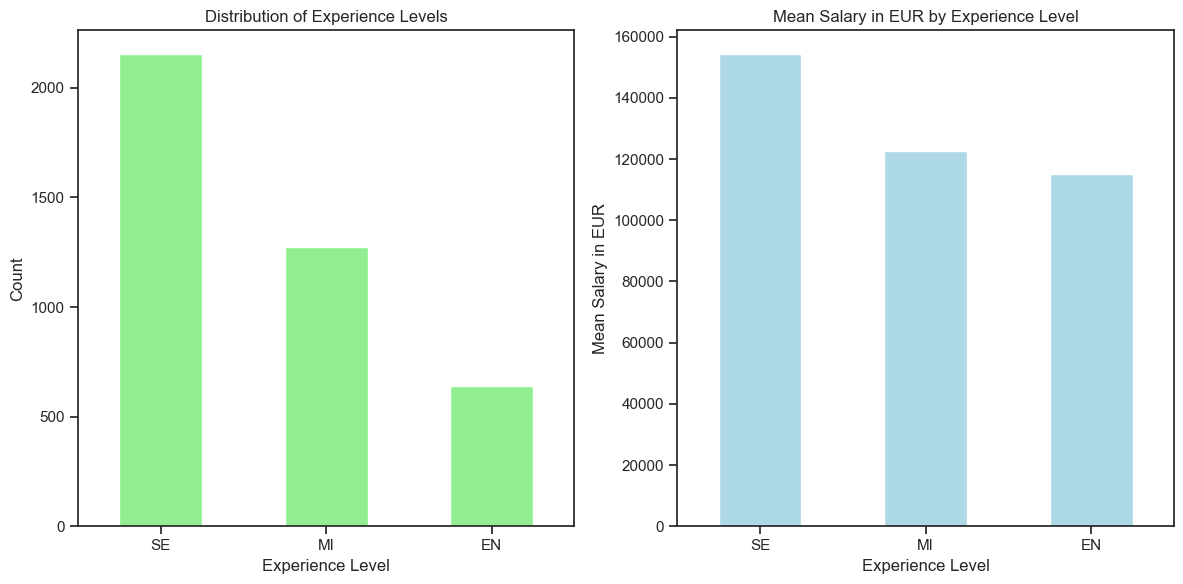

In [536]:
#set variables
experience_counts = df['experience_level'].value_counts()
mean_salary_by_experience = df.groupby('experience_level')['salary_in_eur'].mean()
# set fixed order
mean_salary_by_experience = mean_salary_by_experience.reindex(['SE', 'MI', 'EN'])

plt.figure(figsize=(12, 6))

# distribution of exp level
plt.subplot(1, 2, 1)
experience_counts.plot(kind='bar', color='lightgreen')
plt.title('Distribution of Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.xticks(rotation=0)

# mean salary by exp level
plt.subplot(1, 2, 2)
mean_salary_by_experience.plot(kind='bar', color='lightblue')
plt.title('Mean Salary in EUR by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Mean Salary in EUR')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Senior Engineers occupy more positions and also have a higher salary on average.

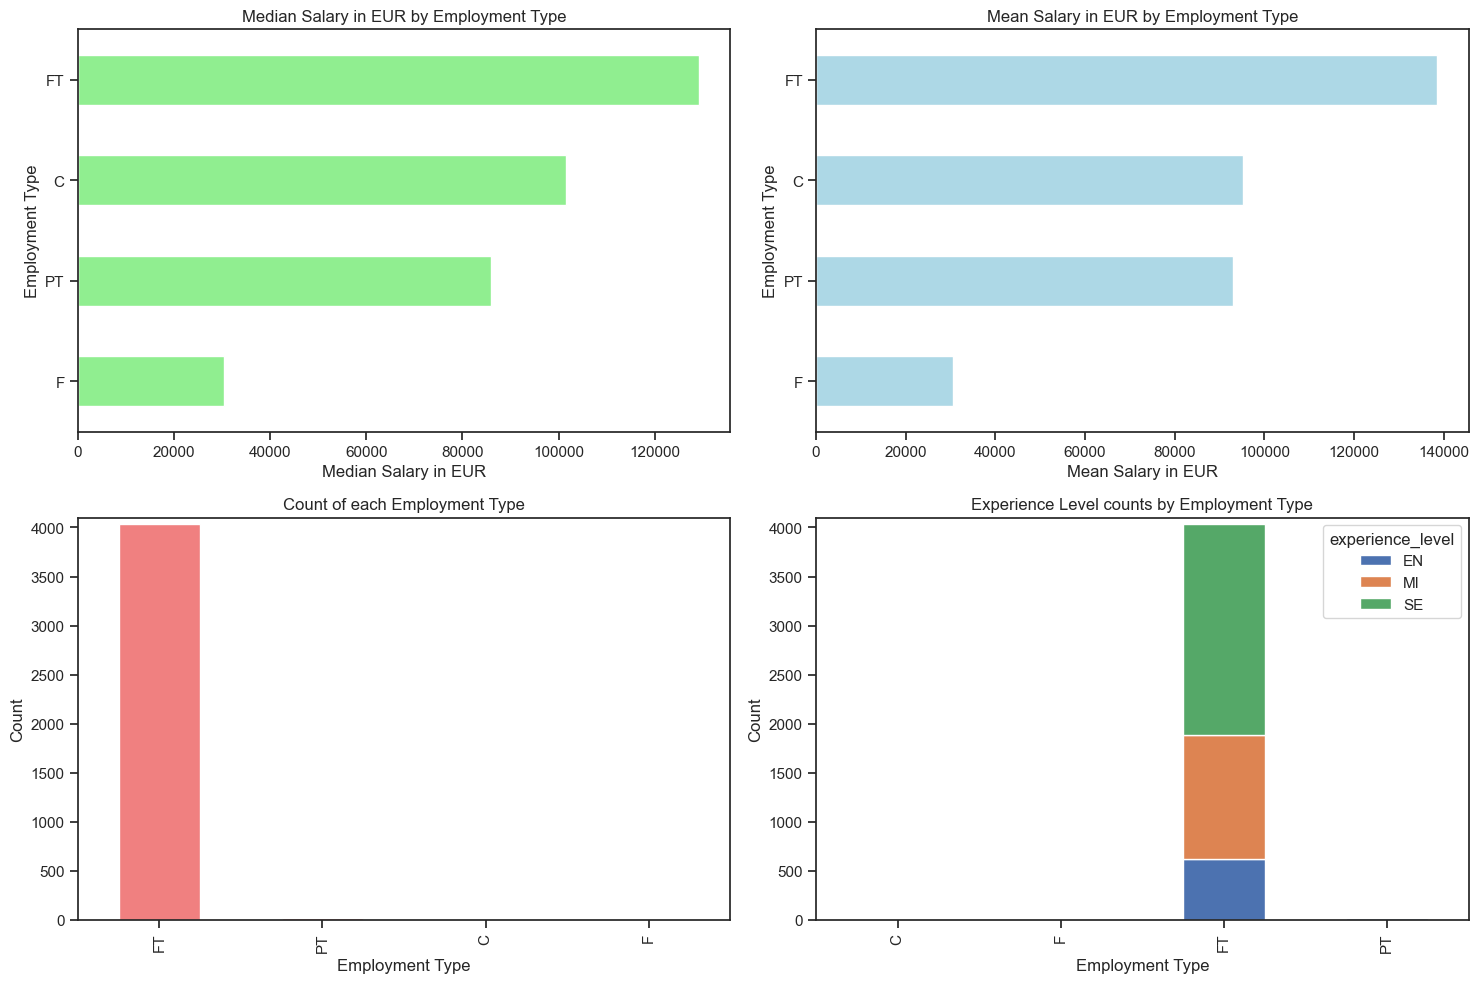

In [537]:
# calculating and setting variables
salary_by_employment_median = df.groupby('employment_type')['salary_in_eur'].median().sort_values()
salary_by_employment_mean = df.groupby('employment_type')['salary_in_eur'].mean().sort_values()
employment_type_counts = df['employment_type'].value_counts()
experience_level_counts = df.groupby(['employment_type', 'experience_level']).size().unstack(fill_value=0)

# Creating subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Median salary
salary_by_employment_median.plot(kind='barh', color='lightgreen', ax=ax1)
ax1.set_title('Median Salary in EUR by Employment Type')
ax1.set_xlabel('Median Salary in EUR')
ax1.set_ylabel('Employment Type')

# Mean salary
salary_by_employment_mean.plot(kind='barh', color='lightblue', ax=ax2)
ax2.set_title('Mean Salary in EUR by Employment Type')
ax2.set_xlabel('Mean Salary in EUR')
ax2.set_ylabel('Employment Type')

# Employment type counts
employment_type_counts.plot(kind='bar', color='lightcoral', ax=ax3)
ax3.set_title('Count of each Employment Type')
ax3.set_xlabel('Employment Type')
ax3.set_ylabel('Count')
ax3.set_ylim(0, 4100)  # Limiting for better readability

# experience level per employment type
experience_level_counts.plot(kind='bar', ax=ax4, stacked=True)
ax4.set_title('Experience Level counts by Employment Type')
ax4.set_xlabel('Employment Type')
ax4.set_ylabel('Count')
ax4.set_ylim(0,4100) # limiting for better readability

plt.tight_layout()
plt.show()


Almost all Employment Types are occupied by Fulltime. On average, fulltime has the highest salary, with freelancers being the lowest.

## Distribution

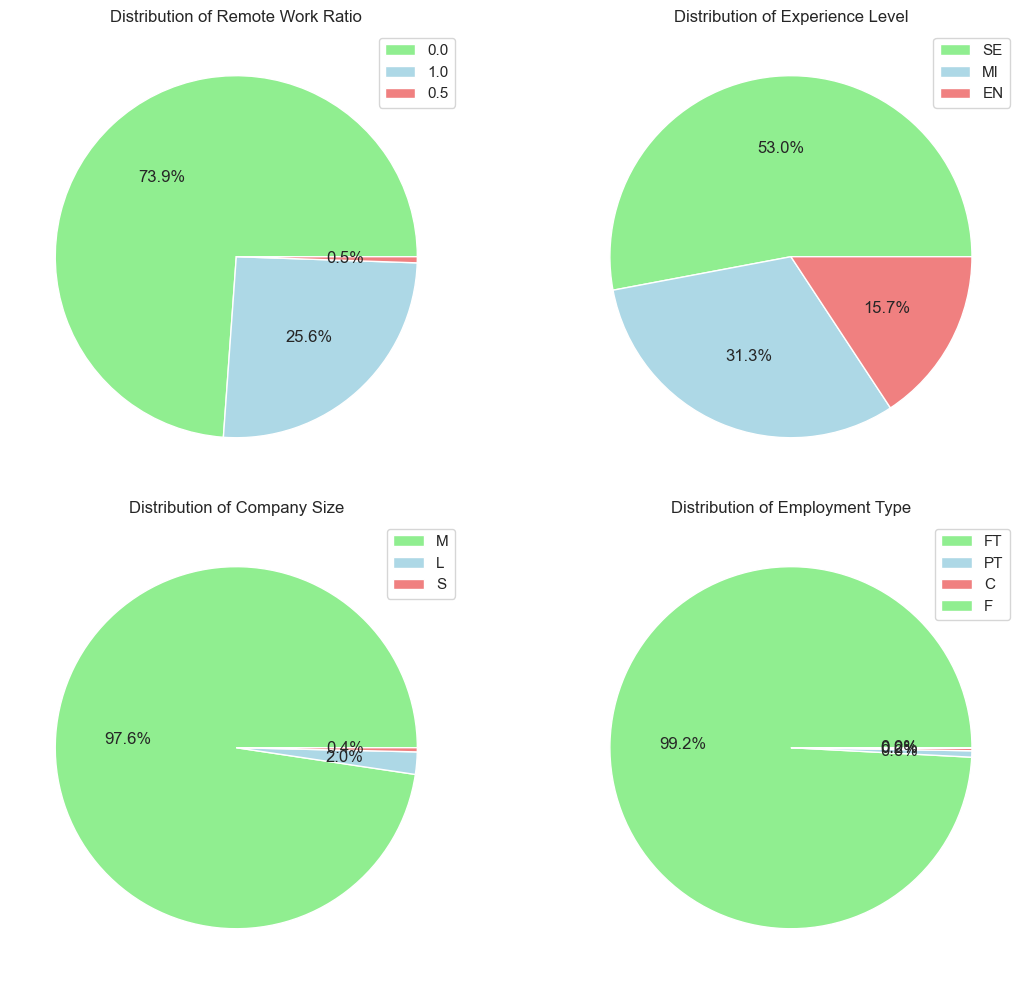

In [538]:
# count each variable
remote_counts = df['remote_ratio'].value_counts()
experience_level_counts = df['experience_level'].value_counts()
company_size_counts = df['company_size'].value_counts()
salary_currency_counts = df['employment_type'].value_counts()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# remote count
remote_pie = axes[0, 0].pie(remote_counts, autopct='%1.1f%%', colors=['lightgreen', 'lightblue', 'lightcoral'])
axes[0, 0].set_title('Distribution of Remote Work Ratio')
axes[0, 0].legend(remote_counts.index, loc="best")

# exp level count
experience_pie = axes[0, 1].pie(experience_level_counts, autopct='%1.1f%%', colors=['lightgreen', 'lightblue', 'lightcoral'])
axes[0, 1].set_title('Distribution of Experience Level')
axes[0, 1].legend(experience_level_counts.index, loc="best")

# comp size count
company_size_pie = axes[1, 0].pie(company_size_counts, autopct='%1.1f%%', colors=['lightgreen', 'lightblue', 'lightcoral'])
axes[1, 0].set_title('Distribution of Company Size')
axes[1, 0].legend(company_size_counts.index, loc="best")

# emp type count
salary_currency_pie = axes[1, 1].pie(salary_currency_counts, autopct='%1.1f%%', colors=['lightgreen', 'lightblue', 'lightcoral'])
axes[1, 1].set_title('Distribution of Employment Type')
axes[1, 1].legend(salary_currency_counts.index, loc="best")

plt.tight_layout()
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


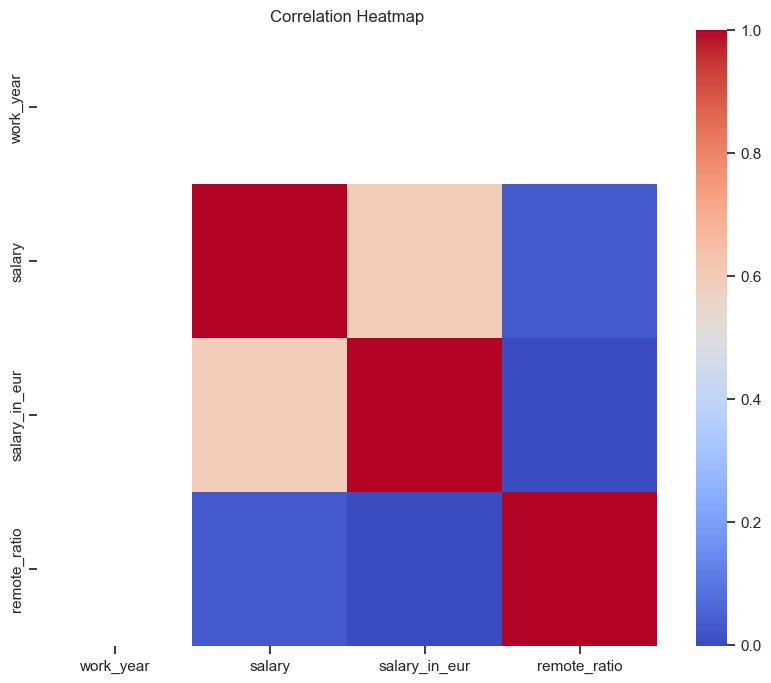

In [539]:
# only allow numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# corr matrix
correlation_matrix = df[numeric_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## What are the best paying popular Data Engineer Jobs 2024?

In [540]:
df.groupby('job_title').count()[df.groupby('job_title').count() > 200].dropna().sort_values(by='work_year', ascending=False)

,work_year,experience_level,employment_type,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
job_title,,,,,,,,,,
Data Scientist,698.0,698.0,698.0,698.0,698.0,698.0,698.0,698.0,698.0,698.0
Data Engineer,640.0,640.0,640.0,640.0,640.0,640.0,640.0,640.0,640.0,640.0
Data Analyst,544.0,544.0,544.0,544.0,544.0,544.0,544.0,544.0,544.0,544.0
Machine Learning Engineer,383.0,383.0,383.0,383.0,383.0,383.0,383.0,383.0,383.0,383.0


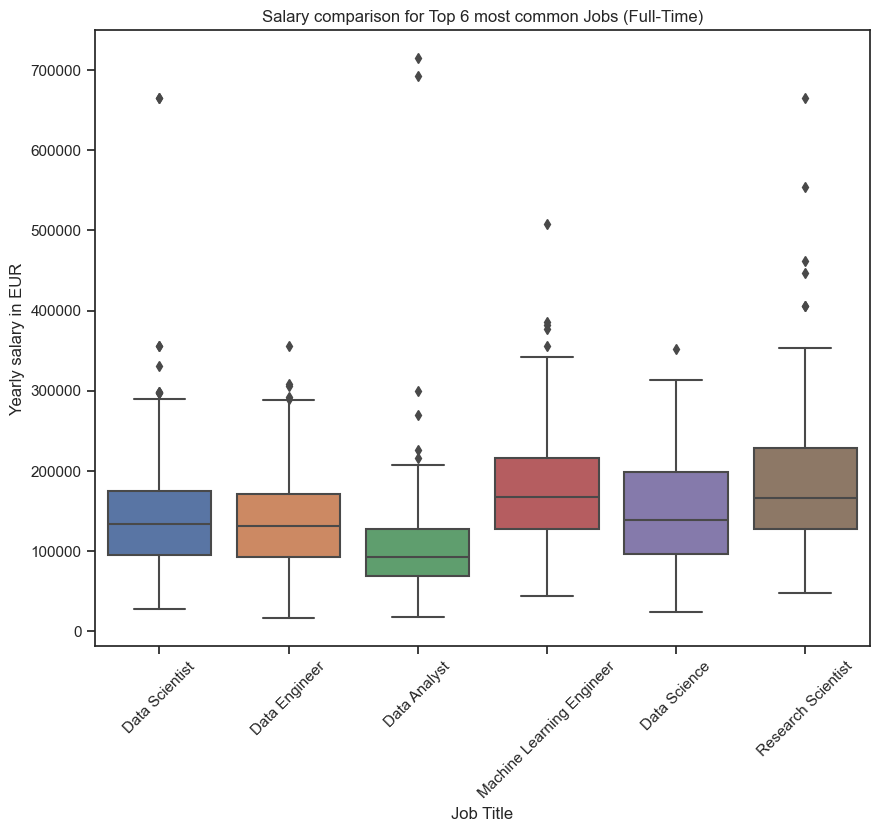

In [541]:
# fixed order, highest count from left to right
job_titles_order = ['Data Scientist', 'Data Engineer', 'Data Analyst', 'Machine Learning Engineer', 'Data Science', 'Research Scientist']

# filter for full time employment only
full_time_df = df[df['employment_type'] == 'FT']

# filter for the top 6 job titles
filtered_df = full_time_df[full_time_df['job_title'].isin(job_titles_order)]

plt.figure(figsize=(10, 8))
sns.boxplot(x='job_title', y='salary_in_eur', data=filtered_df, order=job_titles_order)
plt.title('Salary comparison for Top 6 most common Jobs (Full-Time)')
plt.xlabel('Job Title')
plt.ylabel('Yearly salary in EUR')
plt.xticks(rotation=45)
plt.show()

On average, Machine Learning Engineer and Research Scientist are among the highest earning popular jobs. While Data Analyst seems to be the worst paying among the most popular jobs. Though there can be seen some outliers, it is unsure if that is because of errors.

In [542]:
df[df['salary_in_eur']>300000]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_eur,employee_residence,remote_ratio,company_location,company_size
6,2024,MI,FT,ML Engineer,400000,USD,369323,US,0.0,US,M
309,2024,SE,FT,Data Scientist,385000,USD,355474,US,1.0,US,M
385,2024,SE,FT,Machine Learning Engineer,370000,USD,341624,US,0.0,US,M
393,2024,SE,FT,Analytics Engineer,720000,USD,664782,US,0.0,US,M
629,2024,SE,FT,Analytics Engineer,500000,USD,461654,US,0.0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
5671,2024,SE,FT,ML Engineer,357900,USD,330452,US,0.0,US,M
5679,2024,SE,FT,Applied Scientist,414000,USD,382249,US,0.0,US,M
5689,2024,SE,FT,Data Architect,381500,USD,352242,US,0.0,US,M
5838,2024,MI,FT,Research Engineer,720000,USD,664782,US,0.0,US,M


Either the salary for some jobs are wrong or there are a few very happy Data Engineers.